# Import Dependencies

In [ ]:
!pip install -q transformers datasets accelerate evaluate
!pip install -q torch torchvision torchaudio
!pip install -q scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00


In [ ]:
import re
import random
import pickle
import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Settings

**Seed**

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

**Device**

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
if device.type == "cpu":
    print("⚠️  WARNING: GPU tidak aktif. Training akan lambat.")
    print("    Pergi ke Runtime > Change runtime type > GPU")
else:
    print(f"✅ GPU aktif: {torch.cuda.get_device_name(0)}")

✅ GPU aktif: Tesla T4


# File Loading

In [ ]:
df = pd.read_csv("Combined Data.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (53043, 3)
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [ ]:
selected_labels = [
    "Normal",
    "Depression",
    "Anxiety",
    "Stress"
]

In [ ]:
df = df[df["status"].isin(selected_labels)]

In [ ]:
df = df.dropna(subset=["statement"])

In [ ]:
df = df[["statement", "status"]]

print("\nLabel Distribution (sebelum augmentasi):")
print(df["status"].value_counts())


Label Distribution (sebelum augmentasi):
status
Normal        16343
Depression    15404
Anxiety        3841
Stress         2587
Name: count, dtype: int64


# Data Processing

In [ ]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["statement"] = df["statement"].apply(clean_text)

In [ ]:
anxiety_samples = [

    "my heart races whenever i talk to people",
    "i panic in social situations",
    "i get nervous talking to strangers",
    "small things make me anxious",
    "i cannot stop overthinking",
    "my chest feels tight when i am nervous",
    "i feel anxious around crowds",
    "i worry too much about everything",
    "i feel panic for no reason",
    "my thoughts never stop racing",

    "i feel nervous all the time",
    "i keep thinking something bad will happen",
    "my anxiety gets worse at night",
    "i cannot calm my thoughts",
    "i overthink every conversation",
    "my mind never stops worrying",
    "i feel scared without knowing why",
    "my body shakes when i feel nervous",
    "i struggle to relax around people",
    "i feel uncomfortable in crowded places"

]

In [ ]:
stress_samples = [

    "i feel burned out from studying every day",
    "too many assignments are exhausting me",
    "i feel mentally drained from work",
    "my workload is overwhelming",
    "i am exhausted from constant pressure",
    "studying every day is making me tired",
    "i cannot relax because of deadlines",
    "i feel emotionally exhausted lately",
    "my responsibilities are stressing me out",
    "i feel tired from handling too many things",

    "i have too much work to do",
    "my daily tasks are overwhelming",
    "i feel pressure from my job",
    "my schedule is exhausting",
    "i am mentally tired from studying",
    "i feel stressed about deadlines",
    "my work pressure never stops",
    "i cannot handle all these responsibilities",
    "everything feels overwhelming lately",
    "my brain feels exhausted"

]

In [ ]:
augmentation_df = pd.concat([

    pd.DataFrame({
        "statement": anxiety_samples,
        "status": ["Anxiety"] * len(anxiety_samples)
    }),

    pd.DataFrame({
        "statement": stress_samples,
        "status": ["Stress"] * len(stress_samples)
    })

], ignore_index=True)

In [ ]:
df = pd.concat([
    df,
    augmentation_df
], ignore_index=True)

print("\nLabel Distribution (setelah augmentasi):")
print(df["status"].value_counts())


Label Distribution (setelah augmentasi):
status
Normal        16343
Depression    15404
Anxiety        3861
Stress         2607
Name: count, dtype: int64


# Label Encoding

In [ ]:
le = LabelEncoder()

df["label"] = le.fit_transform(df["status"])

print("\nLabel Mapping:")
for idx, label in enumerate(le.classes_):
    print(f"  {idx} = {label}")


Label Mapping:
  0 = Anxiety
  1 = Depression
  2 = Normal
  3 = Stress


# Train Test Split

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(

    df["statement"],
    df["label"],

    test_size=0.15,
    stratify=df["label"],
    random_state=SEED

)

In [ ]:
print(f"\nTrain size : {len(train_texts)}")
print(f"Test size  : {len(test_texts)}")


Train size : 32482
Test size  : 5733


# TOKENIZATION

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(

    train_texts.tolist(),

    truncation=True,
    padding=True,
    max_length=128

)

In [ ]:
test_encodings = tokenizer(

    test_texts.tolist(),

    truncation=True,
    padding=True,
    max_length=128

)

# Hugging Face Dataset

In [ ]:
train_dataset = Dataset.from_dict({

    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels.tolist()

})

In [ ]:
test_dataset = Dataset.from_dict({

    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_labels.tolist()

})

# Model

In [ ]:
class_weights = compute_class_weight(

    class_weight="balanced",

    classes=np.unique(train_labels),

    y=train_labels

)

In [ ]:
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

In [ ]:
print("\nClass Weights:")
for label, weight in zip(le.classes_, class_weights.cpu().numpy()):
    print(f"  {label}: {weight:.4f}")


Class Weights:
  Anxiety: 2.4743
  Depression: 0.6202
  Normal: 0.5846
  Stress: 3.6645


**Load Model**

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=len(le.classes_)

)

model.to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


**Custom Trainer with Weighted loss**

In [ ]:
class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.get("labels")

        outputs = model(

            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]

        )

        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

**Metrics**

In [ ]:
accuracy_metric = evaluate.load("accuracy")

f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

**Training Args**

In [ ]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    warmup_ratio=0.1,

    lr_scheduler_type="cosine",

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=10,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    logging_dir="./logs",

    logging_steps=100,

    fp16=torch.cuda.is_available(),

    report_to="none"

)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]

)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.398048,0.431027,0.902494,0.904801
2,0.320807,0.360674,0.918193,0.921419
3,0.218095,0.447180,0.930752,0.931067
4,0.149568,0.436924,0.931798,0.933507
5,0.119656,0.526279,0.934415,0.936168
6,0.047339,0.619004,0.938776,0.938696
7,0.047199,0.635123,0.940171,0.940599
8,0.010758,0.635234,0.939299,0.939803
9,0.033397,0.643067,0.941392,0.941736
10,0.003635,0.656420,0.942090,0.942358


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=20310, training_loss=0.15760183381085807, metrics={'train_runtime': 1332.1948, 'train_samples_per_second': 243.823, 'train_steps_per_second': 15.246, 'total_flos': 1.075739878004736e+16, 'train_loss': 0.15760183381085807, 'epoch': 10.0})

# Evaluation

In [ ]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

In [ ]:
print("\nClassification Report:\n")

print(classification_report(

    test_labels,
    preds,

    target_names=le.classes_

))


Classification Report:

              precision    recall  f1-score   support

     Anxiety       0.90      0.92      0.91       579
  Depression       0.97      0.96      0.96      2311
      Normal       0.96      0.96      0.96      2452
      Stress       0.76      0.79      0.77       391

    accuracy                           0.94      5733
   macro avg       0.90      0.90      0.90      5733
weighted avg       0.94      0.94      0.94      5733



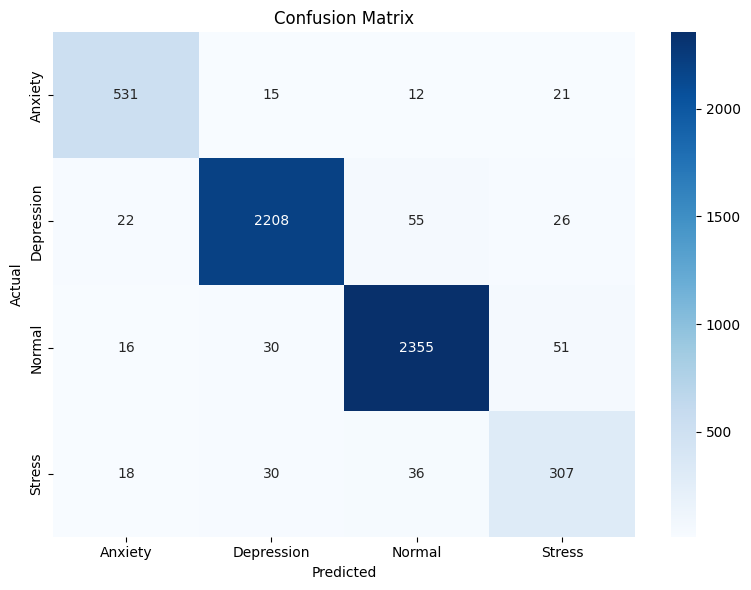

In [ ]:
cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save Model

In [ ]:
trainer.save_model("mental_health_model")

tokenizer.save_pretrained("mental_health_model")

with open("mental_health_model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ Model saved to mental_health_model/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to mental_health_model/


In [ ]:
!zip -r mental_health_model.zip mental_health_model/

from google.colab import files
files.download("mental_health_model.zip")

print("✅ Model downloaded!")

  adding: mental_health_model/ (stored 0%)
  adding: mental_health_model/training_args.bin (deflated 53%)
  adding: mental_health_model/tokenizer_config.json (deflated 42%)
  adding: mental_health_model/tokenizer.json (deflated 71%)
  adding: mental_health_model/config.json (deflated 52%)
  adding: mental_health_model/model.safetensors (deflated 8%)
  adding: mental_health_model/label_encoder.pkl (deflated 18%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded!


# Test Inference

In [ ]:
def predict_text(text):

    cleaned_text = clean_text(text)

    inputs = tokenizer(

        cleaned_text,

        return_tensors="pt",

        truncation=True,

        padding=True,

        max_length=128

    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    model.eval()

    with torch.no_grad():

        outputs = model(**inputs)

        probs = torch.nn.functional.softmax(
            outputs.logits,
            dim=1
        )

    probs = probs.cpu().numpy()[0]

    top2_idx = probs.argsort()[-2:][::-1]

    labels = le.inverse_transform(top2_idx)

    confidence1 = float(probs[top2_idx[0]])
    confidence2 = float(probs[top2_idx[1]])

    prediction = labels[0]

    if confidence1 < 0.60:
        prediction = "Mixed Emotional Indicators"

    return {

        "text": text,

        "prediction": prediction,

        "confidence": round(confidence1, 4),

        "top2": [
            {"label": labels[0], "score": round(confidence1, 4)},
            {"label": labels[1], "score": round(confidence2, 4)}
        ]

    }

In [ ]:
samples = [
    "my heart races whenever i talk to people",
    "i feel burned out from studying every day",
    "i feel hopeless and empty every day",
    "today i feel calm and peaceful"
]

print("\n" + "="*50)
print("INFERENCE TEST")
print("="*50)

for sample in samples:
    result = predict_text(sample)
    print(f"\nText       : {result['text']}")
    print(f"Prediction : {result['prediction']}")
    print(f"Confidence : {result['confidence']:.2%}")
    print(f"Top 2      : {result['top2'][0]['label']} ({result['top2'][0]['score']:.2%}), "
          f"{result['top2'][1]['label']} ({result['top2'][1]['score']:.2%})")



INFERENCE TEST

Text       : my heart races whenever i talk to people
Prediction : Anxiety
Confidence : 99.99%
Top 2      : Anxiety (99.99%), Depression (0.01%)

Text       : i feel burned out from studying every day
Prediction : Stress
Confidence : 100.00%
Top 2      : Stress (100.00%), Anxiety (0.00%)

Text       : i feel hopeless and empty every day
Prediction : Depression
Confidence : 99.99%
Top 2      : Depression (99.99%), Stress (0.01%)

Text       : today i feel calm and peaceful
Prediction : Normal
Confidence : 99.49%
Top 2      : Normal (99.49%), Stress (0.41%)
